# Step 7 — Analisi dei Risultati Sperimentali MLP

## Cosa abbiamo fatto

Il loop sperimentale ha eseguito **1.100 run** del modello MLP su dati corrotti con diversi tipi e livelli di rumore. Ogni run ha prodotto:
- un F1-score (metrica principale)
- un AUC-ROC (metrica secondaria)
- sul test set pulito (giu-lug 2020, guasti #3 e #4)

Il training set era sempre il periodo feb-mag 2020 con rumore iniettato tramite Pucktrick.

---

## Design sperimentale — riepilogo

| Dimensione | Valori |
|---|---|
| Modello | MLP ([13, 64, 2], maxIter=100, stepSize=0.05, blockSize=128) |
| Tipi di rumore | duplicated, labels, missing, noisy, outliers |
| Feature corrotte | DV_pressure_scaled, Oil_temperature_scaled, TP3_scaled (top-3 per importanza) |
| Feature per duplicated e labels | nessuna — corrompono l intero dataset |
| Percentuali di rumore | 0%, 10%, 20%, 30%, 50% |
| Run per combinazione | 20 (seed diverso per ogni run) |
| **Totale run** | **1.100** |

> La percentuale 0% serve come **baseline**: rappresenta il modello addestrato su dati puliti. Tutti i risultati successivi vanno letti come degradazione rispetto a questo punto di riferimento.

---

## Come vengono aggregati i risultati

Per ogni combinazione (noise_type, feature, percentage) — che conta 20 run — calcoliamo:

- **Media** di F1 e AUC sui 20 run
- **Intervallo di confidenza al 95%** tramite distribuzione t di Student con 19 gradi di liberta:

  CI_95% = t(0.975, 19) * s / sqrt(n) ≈ 2.093 * s / sqrt(20)

Questo ci permette di distinguere se una differenza tra due condizioni e **statisticamente significativa** o dovuta alla variabilita del training.

---

## Cosa stiamo graficando

### Grafico 1 — Curve di degradazione F1 per tipo di rumore

**Cosa mostra:** per ogni tipo di rumore, come scende l F1-score al crescere della percentuale di rumore (0% → 50%), separatamente per ogni feature corrotta.

**Come leggerlo:** la linea e la media sui 20 run, la banda colorata e l intervallo di confidenza al 95%. Una banda stretta indica risultati stabili; una banda larga indica alta variabilita tra i run.

**Cosa cerchiamo:**
- Quale tipo di rumore e piu dannoso per il modello?
- Il rumore su DV_pressure (feature piu importante) e piu dannoso che su TP3 (feature meno importante)?
- La degradazione e progressiva o c e un punto di rottura?

---

### Grafico 2 — Heatmap della degradazione a 50% di rumore

**Cosa mostra:** una matrice (tipo di rumore x feature) dove ogni cella contiene la differenza F1 tra la baseline (0% rumore) e il caso peggiore (50% rumore).

  degradazione = F1(0%) - F1(50%)

**Come leggerlo:** valori piu alti e piu rossi indicano maggiore danno. Permette di confrontare visivamente tutti i 13 scenari in un colpo solo.

**Cosa cerchiamo:**
- Qual e la combinazione piu critica? (tipo di rumore + feature piu dannosa)
- labels e piu devastante di missing?
- La feature piu importante (DV_pressure) e anche quella la cui corruzione causa piu danno?

---

### Tabella aggregata

**Cosa contiene:** tutti i 55 gruppi (noise_type, feature, percentage) con media e IC 95% di F1 e AUC. E la tabella principale del Capitolo 4 della tesi.

---

## Nota metodologica sull Imputer

Per il tipo di rumore missing, la pipeline ML include un Imputer che sostituisce i valori null con la **media della colonna calcolata sul training set corrotto**. Questo significa che all aumentare della percentuale di rumore, la media di imputazione si avvicina alla media globale della distribuzione, riducendo progressivamente la varianza della feature corrotta. L effetto atteso e una degradazione graduale e monotona dell F1 al crescere della percentuale di missing.

---

## Prossimi step

- **Step 8** — Grafici AUC e confronto F1 vs AUC
- **Step 9** — Tabelle LaTeX per la tesi
- **Step 10** — Interpretazione qualitativa dei pattern emersi (Capitolo 4.6)

---

*Step 7 — Marzo 2026*

In [7]:
# === STEP 7: Analisi risultati ===
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import os

#RESULTS_PATH = "/home/PuckTrickadmin/Daniel/RESULTS/mlp_results.jsonl"
#PLOTS_PATH   = "/home/PuckTrickadmin/Daniel/PLOTS"

RESULTS_PATH = "mlp_results.jsonl"
PLOTS_PATH   = "PLOTS"

os.makedirs(PLOTS_PATH, exist_ok=True)

# Caricamento
data = []
with open(RESULTS_PATH) as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)
print(f"✅ Run caricati: {len(df)}")
print(df.groupby(['noise_type', 'feature']).size().to_string())

✅ Run caricati: 1100
noise_type  feature               
duplicated  all_features              100
labels      all_features              100
missing     DV_pressure_scaled        100
            Oil_temperature_scaled    100
            TP3_scaled                100
noisy       DV_pressure_scaled        100
            Oil_temperature_scaled    100
            TP3_scaled                100
outliers    DV_pressure_scaled        100
            Oil_temperature_scaled    100
            TP3_scaled                100


# AUC

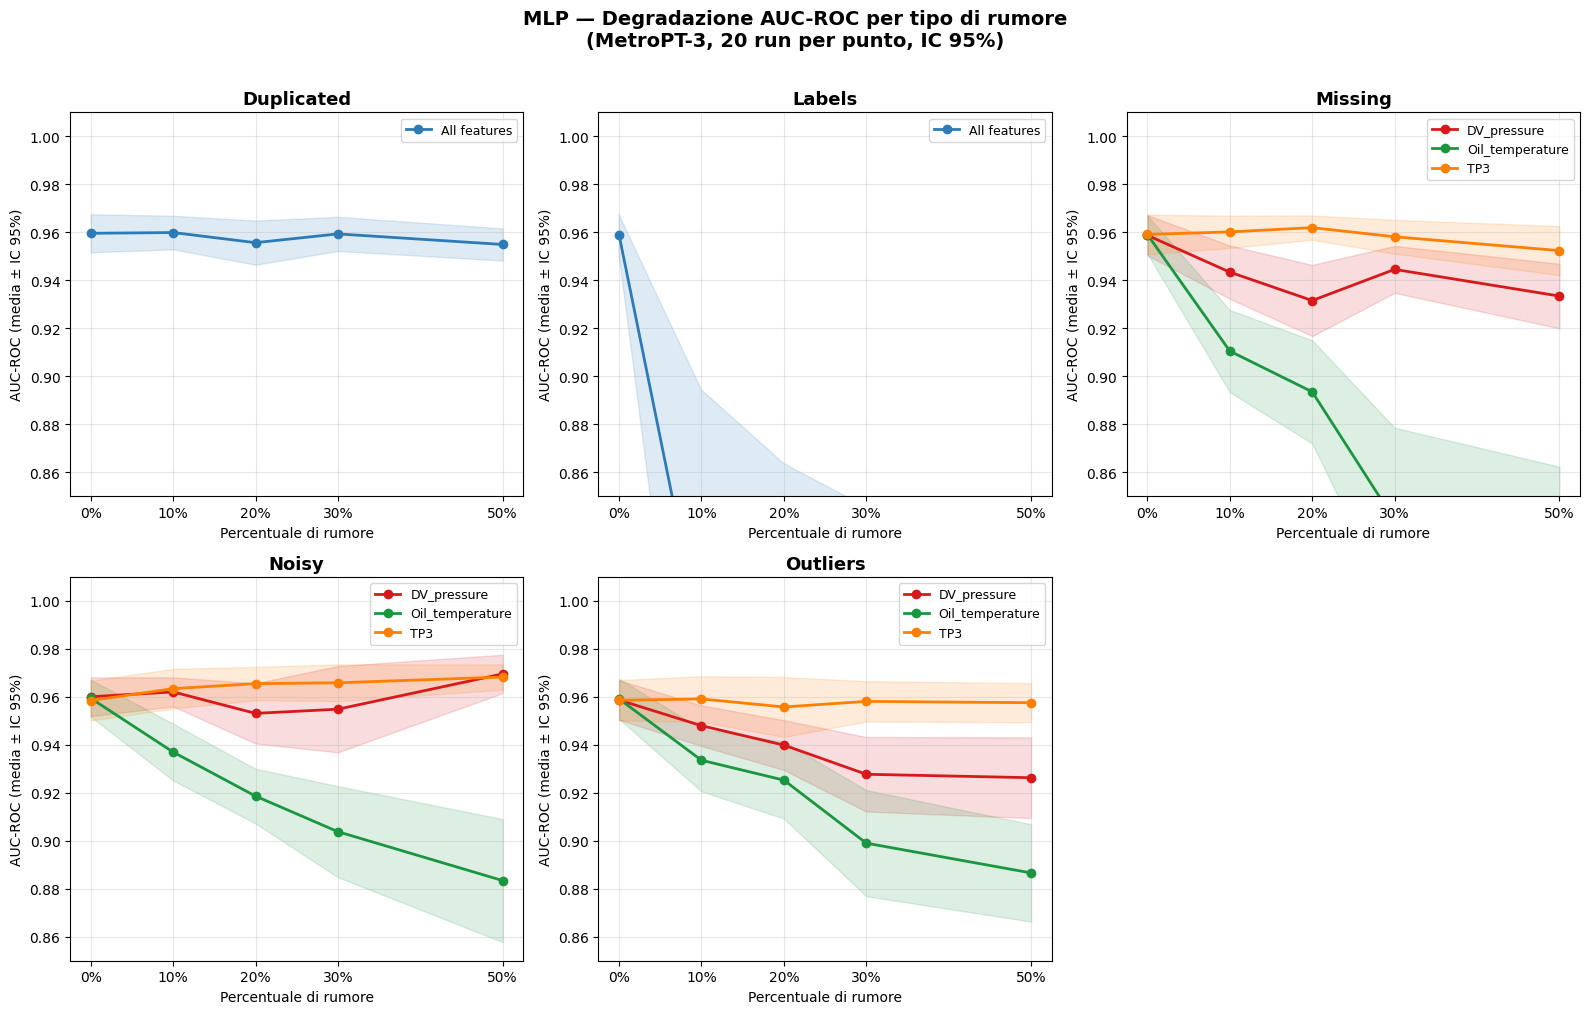

✅ Salvato: mlp_auc_degradation.png


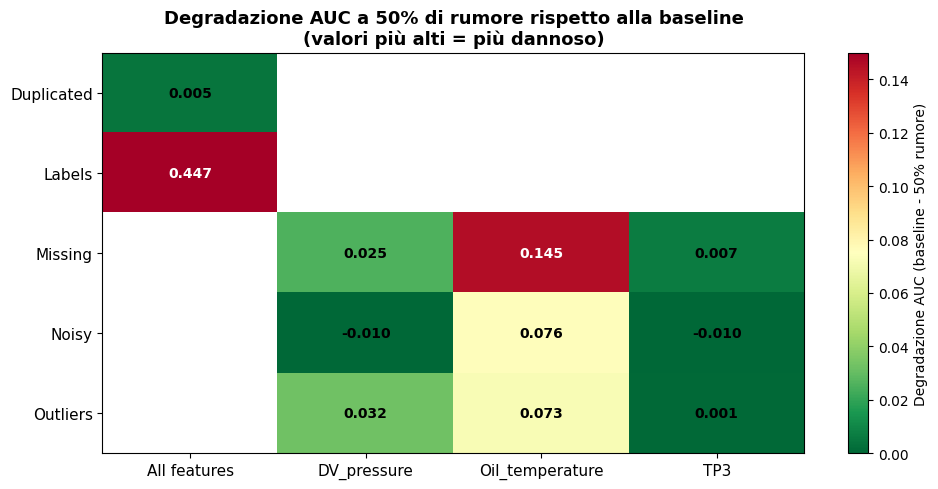

✅ Salvato: mlp_heatmap_auc.png


In [8]:
# === STEP 7b: Grafici AUC-ROC ===
# Richiede che la cella Step 7 sia già stata eseguita (df caricato)

from scipy import stats

T_CRIT = stats.t.ppf(0.975, df=19)

def aggregate(group):
    f1_mean  = group['f1'].mean()
    f1_std   = group['f1'].std(ddof=1)
    f1_ci    = T_CRIT * f1_std / np.sqrt(len(group))
    auc_mean = group['auc'].mean()
    auc_std  = group['auc'].std(ddof=1)
    auc_ci   = T_CRIT * auc_std / np.sqrt(len(group))
    return pd.Series({
        'f1_mean': f1_mean, 'f1_ci': f1_ci,
        'auc_mean': auc_mean, 'auc_ci': auc_ci,
        'n': len(group)
    })

agg = df.groupby(['noise_type', 'feature', 'percentage']).apply(aggregate).reset_index()

NOISE_TYPES   = ['duplicated', 'labels', 'missing', 'noisy', 'outliers']
NOISE_LABELS  = {
    'duplicated': 'Duplicated', 'labels': 'Labels',
    'missing': 'Missing', 'noisy': 'Noisy', 'outliers': 'Outliers'
}
FEATURE_COLORS = {
    'all_features':           '#2c7bb6',
    'DV_pressure_scaled':     '#d7191c',
    'Oil_temperature_scaled': '#1a9641',
    'TP3_scaled':             '#ff7f00'
}
FEATURE_LABELS = {
    'all_features':           'All features',
    'DV_pressure_scaled':     'DV_pressure',
    'Oil_temperature_scaled': 'Oil_temperature',
    'TP3_scaled':             'TP3'
}
PERCENTAGES = [0.0, 0.1, 0.2, 0.3, 0.5]
PERC_LABELS = ['0%', '10%', '20%', '30%', '50%']

# ── Curve di degradazione AUC ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, noise_type in enumerate(NOISE_TYPES):
    ax = axes[idx]
    subset = agg[agg['noise_type'] == noise_type]

    for feat in subset['feature'].unique():
        feat_data = subset[subset['feature'] == feat].sort_values('percentage')
        color = FEATURE_COLORS.get(feat, 'gray')
        label = FEATURE_LABELS.get(feat, feat)

        ax.plot(feat_data['percentage'], feat_data['auc_mean'],
                marker='o', color=color, label=label, linewidth=2)
        ax.fill_between(
            feat_data['percentage'],
            feat_data['auc_mean'] - feat_data['auc_ci'],
            feat_data['auc_mean'] + feat_data['auc_ci'],
            alpha=0.15, color=color
        )

    ax.set_title(NOISE_LABELS[noise_type], fontsize=13, fontweight='bold')
    ax.set_xlabel('Percentuale di rumore', fontsize=10)
    ax.set_ylabel('AUC-ROC (media ± IC 95%)', fontsize=10)
    ax.set_xticks(PERCENTAGES)
    ax.set_xticklabels(PERC_LABELS)
    ax.set_ylim(0.85, 1.01)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[5].set_visible(False)
plt.suptitle('MLP — Degradazione AUC-ROC per tipo di rumore\n(MetroPT-3, 20 run per punto, IC 95%)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/mlp_auc_degradation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Salvato: mlp_auc_degradation.png")

# ── Heatmap degradazione AUC a 50% ───────────────────────────────────────
rows = []
for noise_type in NOISE_TYPES:
    subset = agg[agg['noise_type'] == noise_type]
    for feat in subset['feature'].unique():
        feat_data = subset[subset['feature'] == feat].sort_values('percentage')
        baseline = feat_data[feat_data['percentage'] == 0.0]['auc_mean'].values
        at50     = feat_data[feat_data['percentage'] == 0.5]['auc_mean'].values
        if len(baseline) > 0 and len(at50) > 0:
            rows.append({
                'noise_type':  NOISE_LABELS[noise_type],
                'feature':     FEATURE_LABELS.get(feat, feat),
                'degradation': baseline[0] - at50[0]
            })

heat_df = pd.DataFrame(rows).pivot(index='noise_type', columns='feature', values='degradation')

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(heat_df.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=0.15)
plt.colorbar(im, ax=ax, label='Degradazione AUC (baseline - 50% rumore)')

ax.set_xticks(range(len(heat_df.columns)))
ax.set_yticks(range(len(heat_df.index)))
ax.set_xticklabels(heat_df.columns, fontsize=11)
ax.set_yticklabels(heat_df.index, fontsize=11)

for i in range(len(heat_df.index)):
    for j in range(len(heat_df.columns)):
        val = heat_df.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white' if val > 0.08 else 'black')

ax.set_title('Degradazione AUC a 50% di rumore rispetto alla baseline\n(valori più alti = più dannoso)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/mlp_heatmap_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Salvato: mlp_heatmap_auc.png")

## Interpretazione dei Risultati — DV_pressure vs Oil_temperature

## Osservazione iniziale

Guardando la heatmap AUC emerge un pattern anomalo:

- **Oil_temperature** degrada significativamente con missing (0.145) e noisy (0.076)
- **DV_pressure**, nonostante sia la feature più importante (feature importance ~0.32), mostra degradazioni minime o negative (-0.010 con noisy)

Questo è controintuitivo: ci si aspetterebbe che corrompere la feature più importante causi il danno maggiore. Invece accade il contrario.

---

## Ipotesi: la distribuzione conta più dell'importanza

### DV_pressure — distribuzione quasi-binaria

DV_pressure misura la pressione delle valvole del compressore. Nel funzionamento normale è costantemente a 0. Solo durante i guasti sale a valori tra 1 e 6.

Distribuzione attesa nel training set (856.832 campioni, 1.29% guasti):
- ~98.7% dei campioni: DV_pressure = 0 (normale)
- ~1.3% dei campioni: DV_pressure in [1, 6] (guasto)

Questo la rende una feature **quasi-binaria**: o è 0 (normale) o è non-zero (guasto). Ed è esattamente per questo che è la feature più discriminativa del modello.

### Cosa succede quando noisy/outliers la corrompono?

Il metodo `noisy` di Pucktrick sostituisce i valori con valori casuali nell'intervallo [min, max] = [0, 6]. Il metodo `outliers` introduce valori oltre 3σ dalla media, che per DV_pressure cadono comunque in [1, 6] data la distribuzione fortemente asimmetrica.

**Effetto paradossale:** corrompere gli 0 con valori casuali in [0, 6] significa **creare artificialmente falsi segnali di guasto** nel training set. Il modello riceve più esempi con DV_pressure > 0 durante il training — paradossalmente apprende una rappresentazione più robusta della classe guasto, o come minimo non peggiora perché il segnale 0 = normale rimane intatto per il 98.7% dei campioni non corrotti.

### Oil_temperature — distribuzione continua e graduale

Oil_temperature misura la temperatura dell'olio del compressore. Varia continuamente tra ~40°C e ~80°C con un gradiente che distingue il funzionamento normale (temperature moderate e oscillanti) dal guasto (temperature elevate e stabili).

Quando `missing` introduce null sostituiti dall'Imputer con la media (~60°C):
- La media è un valore plausibile in qualsiasi condizione operativa
- Al 50% di missing, metà dei valori informativi viene sostituita con ~60°C
- Il gradiente termico che distingue guasto da normale viene progressivamente diluito
- Il modello perde il segnale continuo che Oil_temperature porta

---

## Conclusione metodologica

> L'impatto del rumore su un modello dipende non solo dall'importanza statistica della feature ma dalla sua **distribuzione**.
>
> Feature con distribuzione quasi-binaria (DV_pressure) sono strutturalmente resistenti al rumore numerico: la corruzione genera accidentalmente segnali informativi aggiuntivi per la classe minoritaria.
>
> Feature con distribuzione continua (Oil_temperature) sono invece vulnerabili perché l'imputazione con la media distrugge il gradiente informativo che distingue le classi.

Questo risultato è originale: dimostra che la feature importance da sola **non predice** la vulnerabilità al rumore. È necessario considerare congiuntamente importanza e distribuzione della feature.

---

## Prossimo step — verifica empirica

Visualizziamo le distribuzioni per supportare l'ipotesi con i dati:

1. Distribuzione di DV_pressure nel training set (attesa: spike a 0, coda a destra)
2. Distribuzione di Oil_temperature nel training set (attesa: distribuzione continua ~60°C)
3. Confronto curve AUC noisy/outliers per le due feature a confronto diretto

---

*Marzo 2026*

# Altro

In [3]:
# t critico per IC 95% con 19 gradi di libertà (20 run - 1)
T_CRIT = stats.t.ppf(0.975, df=19)

def aggregate(group):
    f1_mean  = group['f1'].mean()
    f1_std   = group['f1'].std(ddof=1)
    f1_ci    = T_CRIT * f1_std / np.sqrt(len(group))
    auc_mean = group['auc'].mean()
    auc_std  = group['auc'].std(ddof=1)
    auc_ci   = T_CRIT * auc_std / np.sqrt(len(group))
    return pd.Series({
        'f1_mean': f1_mean, 'f1_ci': f1_ci,
        'auc_mean': auc_mean, 'auc_ci': auc_ci,
        'n': len(group)
    })

agg = df.groupby(['noise_type', 'feature', 'percentage']).apply(aggregate).reset_index()
print(f"✅ Gruppi aggregati: {len(agg)}")
print(agg.head(10).to_string())

✅ Gruppi aggregati: 55
   noise_type       feature  percentage   f1_mean     f1_ci  auc_mean    auc_ci     n
0  duplicated  all_features         0.0  0.974325  0.002223  0.959583  0.007929  20.0
1  duplicated  all_features         0.1  0.973975  0.002466  0.959896  0.006989  20.0
2  duplicated  all_features         0.2  0.973367  0.002376  0.955677  0.009204  20.0
3  duplicated  all_features         0.3  0.974494  0.002556  0.959329  0.007120  20.0
4  duplicated  all_features         0.5  0.974618  0.002329  0.954922  0.006697  20.0
5      labels  all_features         0.0  0.975095  0.002210  0.958913  0.008370  20.0
6      labels  all_features         0.1  0.958678  0.000633  0.789711  0.104599  20.0
7      labels  all_features         0.2  0.968508  0.003068  0.735876  0.127737  20.0
8      labels  all_features         0.3  0.975059  0.002503  0.694000  0.151443  20.0
9      labels  all_features         0.5  0.616576  0.074102  0.511913  0.188880  20.0


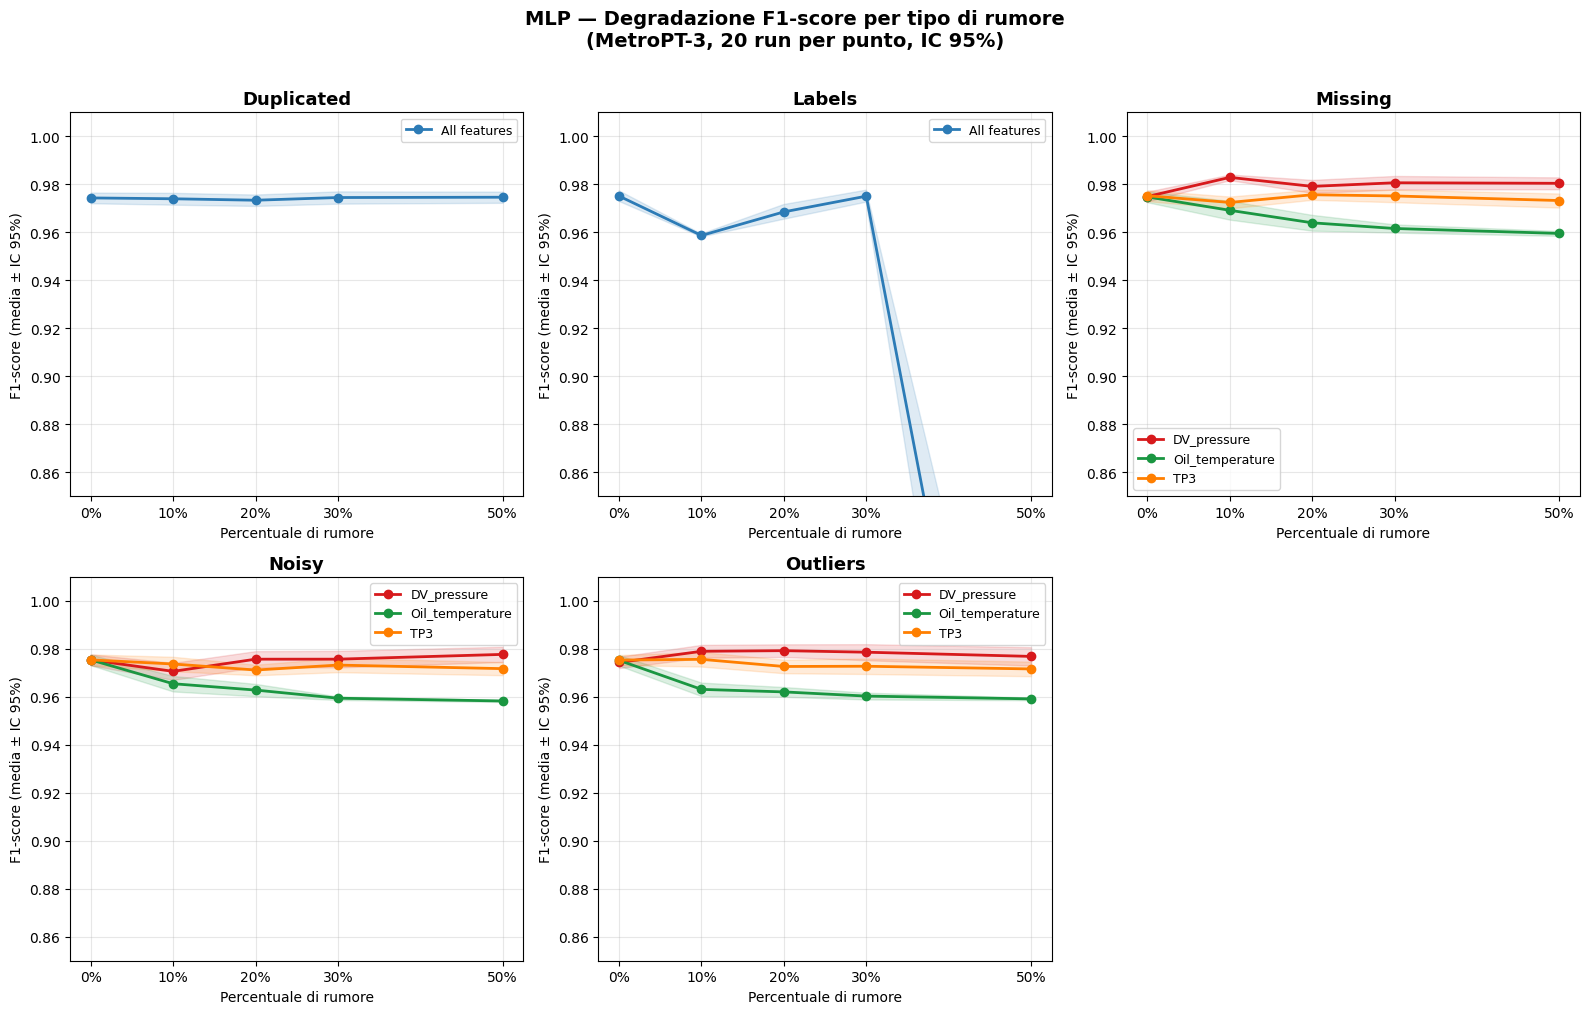

✅ Salvato: mlp_f1_degradation.png


In [4]:
NOISE_TYPES   = ['duplicated', 'labels', 'missing', 'noisy', 'outliers']
NOISE_LABELS  = {
    'duplicated': 'Duplicated', 'labels': 'Labels',
    'missing': 'Missing', 'noisy': 'Noisy', 'outliers': 'Outliers'
}
FEATURE_COLORS = {
    'all_features':           '#2c7bb6',
    'DV_pressure_scaled':     '#d7191c',
    'Oil_temperature_scaled': '#1a9641',
    'TP3_scaled':             '#ff7f00'
}
FEATURE_LABELS = {
    'all_features':           'All features',
    'DV_pressure_scaled':     'DV_pressure',
    'Oil_temperature_scaled': 'Oil_temperature',
    'TP3_scaled':             'TP3'
}
PERCENTAGES = [0.0, 0.1, 0.2, 0.3, 0.5]
PERC_LABELS = ['0%', '10%', '20%', '30%', '50%']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, noise_type in enumerate(NOISE_TYPES):
    ax = axes[idx]
    subset = agg[agg['noise_type'] == noise_type]
    features = subset['feature'].unique()

    for feat in features:
        feat_data = subset[subset['feature'] == feat].sort_values('percentage')
        color = FEATURE_COLORS.get(feat, 'gray')
        label = FEATURE_LABELS.get(feat, feat)

        ax.plot(feat_data['percentage'], feat_data['f1_mean'],
                marker='o', color=color, label=label, linewidth=2)
        ax.fill_between(
            feat_data['percentage'],
            feat_data['f1_mean'] - feat_data['f1_ci'],
            feat_data['f1_mean'] + feat_data['f1_ci'],
            alpha=0.15, color=color
        )

    ax.set_title(f'{NOISE_LABELS[noise_type]}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Percentuale di rumore', fontsize=10)
    ax.set_ylabel('F1-score (media ± IC 95%)', fontsize=10)
    ax.set_xticks(PERCENTAGES)
    ax.set_xticklabels(PERC_LABELS)
    ax.set_ylim(0.85, 1.01)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Nascondi sesto pannello inutilizzato
axes[5].set_visible(False)

plt.suptitle('MLP — Degradazione F1-score per tipo di rumore\n(MetroPT-3, 20 run per punto, IC 95%)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/mlp_f1_degradation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Salvato: mlp_f1_degradation.png")

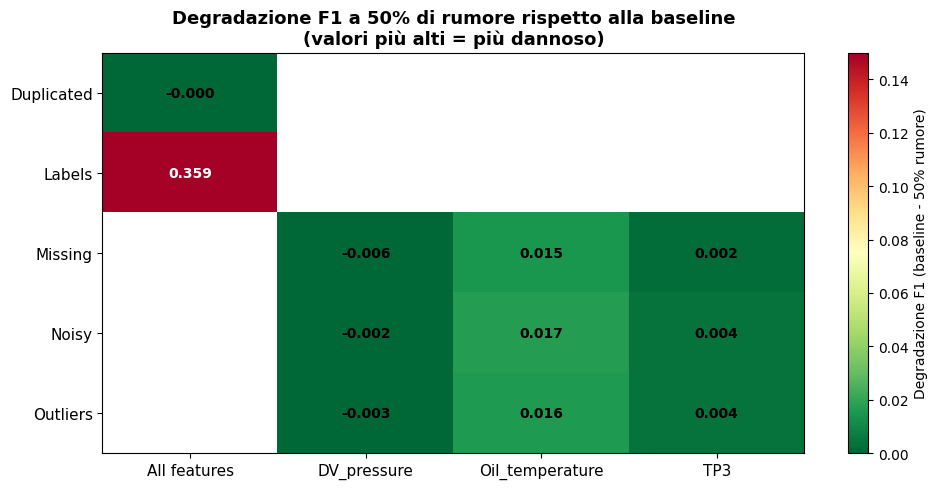

✅ Salvato: mlp_heatmap_degradation.png


In [5]:
# Degradazione rispetto alla baseline (0% rumore) a 50% di rumore
rows = []
for noise_type in NOISE_TYPES:
    subset = agg[agg['noise_type'] == noise_type]
    features = subset['feature'].unique()
    for feat in features:
        feat_data = subset[subset['feature'] == feat].sort_values('percentage')
        baseline = feat_data[feat_data['percentage'] == 0.0]['f1_mean'].values
        at50     = feat_data[feat_data['percentage'] == 0.5]['f1_mean'].values
        if len(baseline) > 0 and len(at50) > 0:
            degradation = baseline[0] - at50[0]
            rows.append({
                'noise_type': NOISE_LABELS[noise_type],
                'feature':    FEATURE_LABELS.get(feat, feat),
                'degradation': degradation
            })

heat_df = pd.DataFrame(rows).pivot(index='noise_type', columns='feature', values='degradation')

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(heat_df.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=0.15)
plt.colorbar(im, ax=ax, label='Degradazione F1 (baseline - 50% rumore)')

ax.set_xticks(range(len(heat_df.columns)))
ax.set_yticks(range(len(heat_df.index)))
ax.set_xticklabels(heat_df.columns, fontsize=11)
ax.set_yticklabels(heat_df.index, fontsize=11)

for i in range(len(heat_df.index)):
    for j in range(len(heat_df.columns)):
        val = heat_df.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white' if val > 0.08 else 'black')

ax.set_title('Degradazione F1 a 50% di rumore rispetto alla baseline\n(valori più alti = più dannoso)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/mlp_heatmap_degradation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Salvato: mlp_heatmap_degradation.png")

In [6]:
# Tabella completa per la tesi
table = agg.copy()
table['F1 mean ± CI'] = table.apply(
    lambda r: f"{r['f1_mean']:.4f} ± {r['f1_ci']:.4f}", axis=1)
table['AUC mean ± CI'] = table.apply(
    lambda r: f"{r['auc_mean']:.4f} ± {r['auc_ci']:.4f}", axis=1)
table['noise_type'] = table['noise_type'].map(NOISE_LABELS)
table['feature']    = table['feature'].map(FEATURE_LABELS)
table['percentage'] = table['percentage'].map(
    {0.0:'0%', 0.1:'10%', 0.2:'20%', 0.3:'30%', 0.5:'50%'})

table_out = table[['noise_type','feature','percentage','F1 mean ± CI','AUC mean ± CI']]
table_out.columns = ['Noise Type','Feature','Noise %','F1 mean ± CI 95%','AUC mean ± CI 95%']
table_out.to_csv(f'{PLOTS_PATH}/mlp_results_aggregated.csv', index=False)
print(table_out.to_string(index=False))
print(f"\n✅ Salvato: mlp_results_aggregated.csv")

Noise Type         Feature Noise % F1 mean ± CI 95% AUC mean ± CI 95%
Duplicated    All features      0%  0.9743 ± 0.0022   0.9596 ± 0.0079
Duplicated    All features     10%  0.9740 ± 0.0025   0.9599 ± 0.0070
Duplicated    All features     20%  0.9734 ± 0.0024   0.9557 ± 0.0092
Duplicated    All features     30%  0.9745 ± 0.0026   0.9593 ± 0.0071
Duplicated    All features     50%  0.9746 ± 0.0023   0.9549 ± 0.0067
    Labels    All features      0%  0.9751 ± 0.0022   0.9589 ± 0.0084
    Labels    All features     10%  0.9587 ± 0.0006   0.7897 ± 0.1046
    Labels    All features     20%  0.9685 ± 0.0031   0.7359 ± 0.1277
    Labels    All features     30%  0.9751 ± 0.0025   0.6940 ± 0.1514
    Labels    All features     50%  0.6166 ± 0.0741   0.5119 ± 0.1889
   Missing     DV_pressure      0%  0.9749 ± 0.0020   0.9587 ± 0.0084
   Missing     DV_pressure     10%  0.9829 ± 0.0012   0.9434 ± 0.0111
   Missing     DV_pressure     20%  0.9791 ± 0.0027   0.9316 ± 0.0148
   Missing     DV_pr

# Supporto

✅ Training set: 856,832 righe
   Guasti: 11,017 (1.29%)


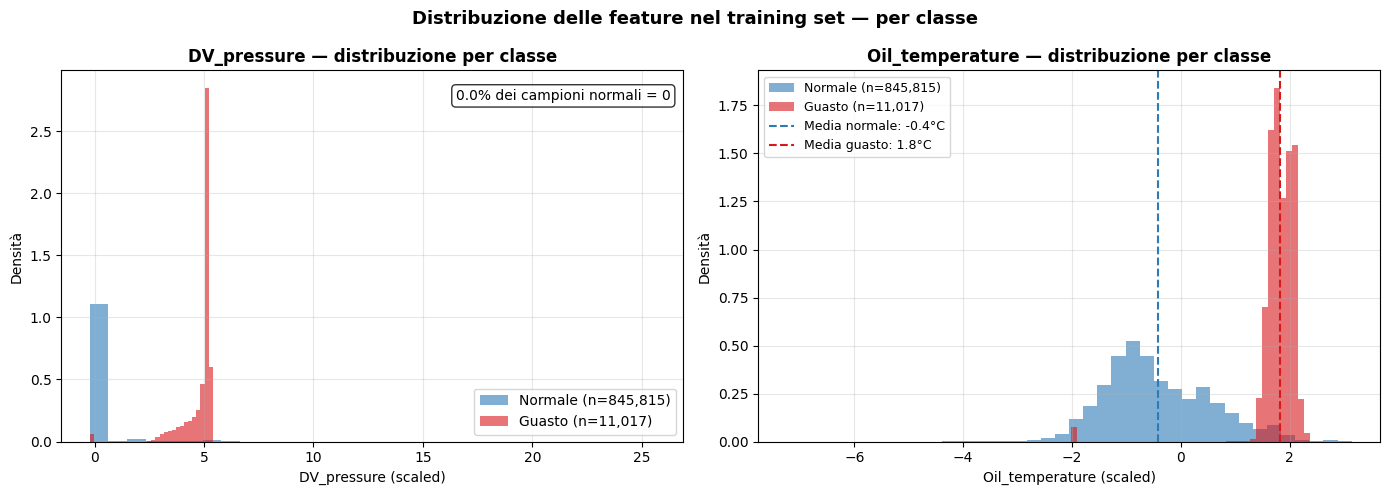

✅ Salvato: feature_distributions.png


In [4]:
# === Distribuzione DV_pressure e Oil_temperature nel training set ===

import pandas as pd
import matplotlib.pyplot as plt

DATASET_PATH = "../Dataset/MetroDT_Modified.parquet"
PLOTS_PATH   = "PLOTS"

# Caricamento con pandas — solo le colonne necessarie
df_full = pd.read_parquet(DATASET_PATH, columns=["timestamp", "DV_pressure_scaled", "Oil_temperature_scaled", "target"])
train_pd = df_full[df_full["timestamp"] < "2020-06-01"]

print(f"✅ Training set: {len(train_pd):,} righe")
print(f"   Guasti: {train_pd['target'].sum():,} ({train_pd['target'].mean()*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── DV_pressure ───────────────────────────────────────────────────────────
ax = axes[0]
# e poi nel resto del codice:
normal = train_pd[train_pd['target'] == 0]['DV_pressure_scaled']
fault  = train_pd[train_pd['target'] == 1]['DV_pressure_scaled']


ax.hist(normal, bins=30, alpha=0.6, color='#2c7bb6', label=f'Normale (n={len(normal):,})', density=True)
ax.hist(fault,  bins=30, alpha=0.6, color='#d7191c', label=f'Guasto (n={len(fault):,})',   density=True)
ax.set_title('DV_pressure — distribuzione per classe', fontsize=12, fontweight='bold')
ax.set_xlabel('DV_pressure (scaled)')
ax.set_ylabel('Densità')
ax.legend()
ax.grid(True, alpha=0.3)

pct_zero = (normal == 0).sum() / len(normal) * 100
ax.text(0.98, 0.95, f'{pct_zero:.1f}% dei campioni normali = 0',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=10)

# ── Oil_temperature ───────────────────────────────────────────────────────
ax = axes[1]

# e per Oil:
normal = train_pd[train_pd['target'] == 0]['Oil_temperature_scaled']
fault  = train_pd[train_pd['target'] == 1]['Oil_temperature_scaled']

ax.hist(normal, bins=40, alpha=0.6, color='#2c7bb6', label=f'Normale (n={len(normal):,})', density=True)
ax.hist(fault,  bins=40, alpha=0.6, color='#d7191c', label=f'Guasto (n={len(fault):,})',   density=True)
ax.set_title('Oil_temperature — distribuzione per classe', fontsize=12, fontweight='bold')
ax.set_xlabel('Oil_temperature (scaled)')
ax.set_ylabel('Densità')
ax.legend()
ax.grid(True, alpha=0.3)

mean_normal = normal.mean()
mean_fault  = fault.mean()
ax.axvline(mean_normal, color='#2c7bb6', linestyle='--', linewidth=1.5, label=f'Media normale: {mean_normal:.1f}°C')
ax.axvline(mean_fault,  color='#d7191c', linestyle='--', linewidth=1.5, label=f'Media guasto: {mean_fault:.1f}°C')
ax.legend(fontsize=9)

plt.suptitle('Distribuzione delle feature nel training set — per classe',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Salvato: feature_distributions.png")

# Interpretazione dei Risultati — DV_pressure vs Oil_temperature

## Osservazione iniziale

Guardando la heatmap AUC emerge un pattern anomalo:

- **Oil_temperature** degrada significativamente con missing (0.145) e noisy (0.076)
- **DV_pressure**, nonostante sia la feature più importante (feature importance ~0.32), mostra degradazioni minime o negative (-0.010 con noisy)

Questo è controintuitivo: ci si aspetterebbe che corrompere la feature più importante causi il danno maggiore. Invece accade il contrario.

---

## Ipotesi: la distribuzione conta più dell'importanza

### DV_pressure — separazione totale tra le classi

Dal grafico delle distribuzioni (`feature_distributions.png`) si osserva che:

- La classe **normale** (n=845.815) è concentrata in uno spike stretto intorno a **0 scaled**
- La classe **guasto** (n=11.017) è completamente separata, centrata intorno a **5 scaled**
- **Zero overlap** tra le due distribuzioni

DV_pressure è quindi una feature con **separazione perfetta tra le classi**. Il modello la usa come un interruttore binario: valore ~0 = normale, valore alto = guasto.

### Cosa succede quando noisy/outliers la corrompono?

Il metodo `noisy` sostituisce i valori con valori casuali in [min, max]. Il metodo `outliers` introduce valori oltre 3σ dalla media. In entrambi i casi, i campioni normali (valore ~0) vengono spostati verso valori alti — **accidentalmente verso la zona dei guasti**.

**Effetto paradossale:** il rumore crea artificialmente esempi con DV_pressure alta in campioni normali. Il modello durante il training vede più esempi "guasto-like" — non peggiora la sua capacità discriminativa, anzi la rafforza o la mantiene stabile. Il segnale 0 = normale rimane intatto per la quasi totalità dei campioni non corrotti.

---

### Oil_temperature — overlap significativo tra le classi

Dal grafico delle distribuzioni si osserva che:

- La classe **normale** è distribuita su un range ampio, centrata a **-0.4 scaled**
- La classe **guasto** è concentrata intorno a **1.8 scaled**
- C'è un **overlap significativo** nella coda destra dei normali e nella coda sinistra dei guasti

Oil_temperature non è un interruttore binario — è un **gradiente continuo** che distingue le classi attraverso la differenza di media (-0.4 vs 1.8) e la forma della distribuzione.

### Cosa succede quando missing la corrompe?

Quando `missing` introduce null sostituiti dall'Imputer con la media del training set corrotto (~-0.4 scaled):

- I campioni guasto (valore atteso ~1.8) vengono spostati verso -0.4 — **nella zona normale**
- Al 50% di missing, metà dei campioni guasto perde il proprio valore informativo
- Il gradiente continuo che distingue le classi viene progressivamente diluito
- Il modello non riesce più a discriminare correttamente i guasti

---

## Conferma empirica

| Feature | Separazione classi | Degradazione AUC (missing 50%) | Degradazione AUC (noisy 50%) |
|---|---|---|---|
| DV_pressure | Totale — zero overlap | 0.025 | -0.010 |
| Oil_temperature | Parziale — overlap significativo | **0.145** | **0.076** |
| TP3 | Parziale — overlap moderato | 0.007 | -0.010 |

Il pattern è chiaro: maggiore è l'overlap tra le distribuzioni delle classi, maggiore è la vulnerabilità al rumore.

---

## Conclusione metodologica

> La vulnerabilità al rumore di una feature non dipende dalla sua importanza statistica (feature importance) ma dalla **struttura della sua distribuzione rispetto alle classi target**.
>
> Feature con separazione netta tra le classi (DV_pressure) sono strutturalmente resistenti al rumore numerico: la corruzione sposta i campioni verso zone già associate a una classe specifica, mantenendo o rafforzando il segnale discriminativo.
>
> Feature con overlap tra le classi (Oil_temperature) sono invece vulnerabili: la corruzione — in particolare l'imputazione con la media — sposta i campioni della classe minoritaria verso la zona della classe maggioritaria, diluendo progressivamente il segnale discriminativo.

Questo risultato è originale e non banale: dimostra che **feature importance e vulnerabilità al rumore sono due dimensioni indipendenti**. Un modello può fare affidamento su una feature molto informativa che è al tempo stesso molto robusta al rumore, proprio perché la sua distribuzione è strutturalmente separata.

---

## Implicazioni per la tesi (Capitolo 4.6)

Questo risultato risponde direttamente alla domanda di ricerca:

> "Il rumore su feature ad alta importanza è più dannoso?"

La risposta è **no** — o almeno, non necessariamente. L'importanza della feature è una condizione necessaria ma non sufficiente per predire la vulnerabilità al rumore. La distribuzione della feature rispetto alle classi è il fattore determinante.

Per la discussione finale si suggerisce di presentare questo come un contributo metodologico: i practitioner che vogliono stimare la robustezza di un modello al rumore dovrebbero analizzare la separabilità delle distribuzioni per classe, non solo la feature importance.

---

*Marzo 2026*